from pymatgen.io.vasp import Chgcar
chg0 = Chgcar.from_file("AECCAR0")
chg2 = Chgcar.from_file("AECCAR2")
chg_total = chg0 + chg2
chg_total.write_file("CHGCAR_total")

In [ ]:
!/usr/bin/env python3

Processing folder: GaO_dipole

  GRID BASED BADER ANALYSIS  (Version 1.05 08/19/23)

  OPEN ... CHGCAR              
  VASP5-STYLE INPUT FILE
  DENSITY-GRID:   56 x 160 x 840
  CLOSE ... CHGCAR              
  RUN TIME:    1.49 SECONDS

  OPEN ... CHGCAR_sum          
  VASP5-STYLE INPUT FILE
  DENSITY-GRID:   56 x 160 x 840
  CLOSE ... CHGCAR_sum          
  RUN TIME:    1.31 SECONDS

  CALCULATING BADER CHARGE DISTRIBUTION
                 0  10  25  50  75  100
  PERCENT DONE:  ********************** 

  REFINING AUTOMATICALLY
  ITERATION: 1
  EDGE POINTS:       3880662
  REASSIGNED POINTS:  228594

  RUN TIME:      17.38 SECONDS

  CALCULATING MINIMUM DISTANCES TO ATOMS
                 0  10  25  50  75  100
  PERCENT DONE:  **********************
  RUN TIME:    1.56 SECONDS

  WRITING BADER ATOMIC CHARGES TO ACF.dat
  WRITING BADER VOLUME CHARGES TO BCF.dat

  NUMBER OF BADER MAXIMA FOUND:         102688
      SIGNIFICANT MAXIMA FOUND:             30
                 VACUUM CHARG

In [1]:
import os
import subprocess
import shutil

# Define folders to process
folders = ["inter_dipole", "GaO_dipole", "SiCH_dipole"]

for folder in folders:
    print(f"Processing folder: {folder}")
    if not os.path.isdir(folder):
        print(f"  Skipping: '{folder}' does not exist.")
        continue

    chgcar_path = os.path.join(folder, "CHGCAR")
    ref_path = os.path.join(folder, "CHGCAR_sum")
    acf_path = os.path.join(folder, "ACF.dat")

    if not os.path.isfile(chgcar_path) or not os.path.isfile(ref_path):
        print(f"  Missing CHGCAR or CHGCAR_sum in '{folder}'. Skipping.")
        continue

    # Run Bader analysis
    try:
        subprocess.run(["bader", "CHGCAR", "-ref", "CHGCAR_sum"], cwd=folder, check=True)
        print(f"  ✅ Bader analysis completed.")
    except subprocess.CalledProcessError as e:
        print(f"  ❌ Error running bader in '{folder}': {e}")
        continue

    # Copy and rename ACF.dat
    target_name = f"ACF_{folder}.dat"
    try:
        shutil.copy(acf_path, target_name)
        print(f"  📄 Copied and renamed to: {target_name}")
    except Exception as e:
        print(f"  ❌ Failed to copy ACF.dat from {folder}: {e}")


Processing folder: inter_dipole
  Missing CHGCAR or CHGCAR_sum in 'inter_dipole'. Skipping.
Processing folder: GaO_dipole
  Missing CHGCAR or CHGCAR_sum in 'GaO_dipole'. Skipping.
Processing folder: SiCH_dipole
  Missing CHGCAR or CHGCAR_sum in 'SiCH_dipole'. Skipping.


In [4]:
def parse_bader(filename="ACF.dat"):
    charges = []
    start_parsing = False
    with open(filename, 'r') as f:
        for line in f:
            if '----' in line:
                start_parsing = True
                continue
            if start_parsing:
                if line.strip() == '':
                    continue
                parts = line.split()
                if len(parts) < 5:
                    continue
                try:
                    charge = float(parts[4])
                    charges.append(charge)
                except ValueError:
                    continue

    total_charge = sum(charges)
    print(f"Number of atoms: {len(charges)}")
    print(f"Total Bader charge: {total_charge:.4f}")
    print("First 10 atomic charges:")
    for i, c in enumerate(charges[:10]):
        print(f"Atom {i+1}: {c:.4f}")

import pandas as pd

# === Function to load and parse ACF.dat files ===
def load_bader_acf(filepath):
    df = pd.read_csv(filepath, sep=r"\s+", skiprows=2, header=None,
                     names=["#", "X", "Y", "Z", "CHARGE", "MIN_DIST", "ATOMIC_VOL"],
                     comment="-")
    df = df.dropna().reset_index(drop=True)  # Ensure clean rows
    return df


# === Load files ===
df_interface = load_bader_acf("inter_dipole/ACF.dat")
df_Ga2O3 = load_bader_acf("GaO_dipole/ACF.dat")  # 30 atoms
df_SiC = load_bader_acf("SiCH_dipole/ACF.dat")      # 39 atoms

# === Ga2O3 part: interface 1–30
df_ga2o3_part = df_interface.iloc[0:30].copy()
df_ga2o3_part["reference_charge"] = df_Ga2O3["CHARGE"].values[:30]
df_ga2o3_part["delta_charge"] = df_ga2o3_part["CHARGE"] - df_ga2o3_part["reference_charge"]
df_ga2o3_part["region"] = "Ga2O3"

# === SiC part: interface 31–69 (39 atoms)
df_sic_part = df_interface.iloc[30:69].copy()
df_sic_part["reference_charge"] = df_SiC["CHARGE"].values[:39]
df_sic_part["delta_charge"] = df_sic_part["CHARGE"] - df_sic_part["reference_charge"]
df_sic_part["region"] = "SiC"

# === Combine and save
df_combined = pd.concat([df_ga2o3_part, df_sic_part], ignore_index=True)
df_combined = df_combined[["#", "region", "CHARGE", "reference_charge", "delta_charge"]]

# Save
df_combined.to_excel("bader_charge_transfer.xlsx", index=False)
print("Saved to bader_charge_transfer.xlsx")

Saved to bader_charge_transfer.xlsx


if __name__ == "__main__":
    parse_bader()

In [7]:
# === Example: calculate total charge transfer for specific atom indices ===
# Provide atom numbers as 1-based index (e.g., from ACF.dat)
target_atoms = [1,2,	3,	4,	13,	14,	15,	16,	17,	18,	40,	41,	42,	46,	47,	48,	55,	56,	57,	64,	65,	66]  # You can modify this list

# Convert to 0-based index for pandas
target_indices = [i - 1 for i in target_atoms]

# Compute sums
subset = df_combined.iloc[target_indices]
sum_charge = subset["CHARGE"].sum()
sum_ref = subset["reference_charge"].sum()
sum_delta = subset["delta_charge"].sum()

print("\n--- Charge Summary for Selected Atoms ---")
print(f"Atom indices: {target_atoms}")
print(f"Total Bader charge: {sum_charge:.4f}")
print(f"Total reference charge: {sum_ref:.4f}")
print(f"Total charge transfer (ΔQ): {sum_delta:.4f} e")


--- Charge Summary for Selected Atoms ---
Atom indices: [1, 2, 3, 4, 13, 14, 15, 16, 17, 18, 40, 41, 42, 46, 47, 48, 55, 56, 57, 64, 65, 66]
Total Bader charge: 136.1102
Total reference charge: 136.1505
Total charge transfer (ΔQ): -0.0403 e


In [ ]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from pymatgen.io.vasp.outputs import Chgcar

# ============================================================
# User knobs
# ============================================================
# CHGCAR_INTERFACE = "inter_dipole/CHGCAR_sum"
# CHGCAR_SIC       = "SiCH_dipole/CHGCAR_sum"
# CHGCAR_GAO       = "GaO_dipole/CHGCAR_sum"
CHGCAR_INTERFACE = "inter_dipole/CHGCAR_sum"
CHGCAR_SIC       = "inter_dipole//CHGCAR_SiC"
CHGCAR_GAO       = "inter_dipole//CHGCAR_Ga2O3"

OUT_CHGDIFF      = "CHGDIFF.vasp"

AXIS             = 2   # 0=x, 1=y, 2=z ; interface normal usually z
MAKE_DIFF        = True

PLOT_DIFF        = "charge_density_difference.png"
PLOT_INT         = "integrated_charge_density.png"

TXT_DIFF         = "rho_ave_z.txt"
TXT_INT          = "rho_integrated_z.txt"

FIG_DPI          = 300
# ============================================================


def check_same_grid(chg_if, chg1, chg2):
    s_if = chg_if.data["total"].shape
    s_1  = chg1.data["total"].shape
    s_2  = chg2.data["total"].shape
    print("Grid shapes:")
    print("interface :", s_if)
    print("SiC       :", s_1)
    print("Ga2O3     :", s_2)
    if not (s_if == s_1 == s_2):
        raise ValueError("CHGCAR grids do not match. Use matched files from the same interface setup.")


def get_grid_axis_length(chg, axis):
    if axis == 0:
        return chg.structure.lattice.a
    elif axis == 1:
        return chg.structure.lattice.b
    elif axis == 2:
        return chg.structure.lattice.c
    else:
        raise ValueError("AXIS must be 0, 1, or 2")


def build_chgdiff():
    print("Reading charge densities...")
    chg_if = Chgcar.from_file(CHGCAR_INTERFACE)
    chg1   = Chgcar.from_file(CHGCAR_SIC)
    chg2   = Chgcar.from_file(CHGCAR_GAO)
    print(chg_if.data["total"].shape)
    print(chg1.data["total"].shape)
    print(chg2.data["total"].shape)

    check_same_grid(chg_if, chg1, chg2)

    print("Building charge density difference:")
    print("rho_diff = rho_interface - rho_SiC - rho_Ga2O3")
    chg_diff = chg_if - (chg1 + chg2)

    print(f"Writing {OUT_CHGDIFF}")
    chg_diff.write_file(OUT_CHGDIFF)
    return chg_diff


def load_chgdiff():
    print(f"Loading {OUT_CHGDIFF}")
    return Chgcar.from_file(OUT_CHGDIFF)


def main():
    if MAKE_DIFF:
        chg_diff = build_chgdiff()
    else:
        chg_diff = load_chgdiff()

    # planar average along chosen axis
    rho_avg = chg_diff.get_average_along_axis(AXIS)

    L = get_grid_axis_length(chg_diff, AXIS)
    ngrid = len(rho_avg)
    coord = np.linspace(0.0, L, ngrid, endpoint=False)
    dcoord = L / ngrid

    # integrated profile
    rho_int = np.cumsum(rho_avg) * dcoord

    # save txt
    np.savetxt(
        TXT_DIFF,
        np.column_stack([coord, rho_avg]),
        header="coord_A   rho_avg_e_per_A3"
    )
    np.savetxt(
        TXT_INT,
        np.column_stack([coord, rho_int]),
        header="coord_A   integrated_rho"
    )

    # plot planar-averaged charge density difference
    plt.figure(figsize=(7, 5))
    plt.plot(coord, rho_avg, lw=1.8)
    plt.axhline(0.0, color="k", lw=0.8, alpha=0.6)
    plt.xlabel(["x", "y", "z"][AXIS] + " (Å)")
    plt.ylabel(r"$\Delta \rho$ (e/Å$^3$)")
    plt.title("Planar-Averaged Charge Density Difference")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIFF, dpi=FIG_DPI, bbox_inches="tight")
    plt.close()

    # plot integrated charge profile
    plt.figure(figsize=(7, 5))
    plt.plot(coord, rho_int, lw=1.8)
    plt.axhline(0.0, color="k", lw=0.8, alpha=0.6)
    plt.xlabel(["x", "y", "z"][AXIS] + " (Å)")
    plt.ylabel(r"$\int \Delta \rho \, d%s$" % ["x", "y", "z"][AXIS])
    plt.title("Integrated Charge Density Difference")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_INT, dpi=FIG_DPI, bbox_inches="tight")
    plt.close()

    print("Done.")
    print(f"Saved: {OUT_CHGDIFF}")
    print(f"Saved: {TXT_DIFF}")
    print(f"Saved: {TXT_INT}")
    print(f"Saved: {PLOT_DIFF}")
    print(f"Saved: {PLOT_INT}")


if __name__ == "__main__":
    main()

Reading charge densities...
Grid shapes:
interface : (56, 300, 672)
SiC       : (56, 160, 840)
Ga2O3     : (56, 160, 840)


ValueError: CHGCAR grids do not match. Use matched files from the same interface setup.

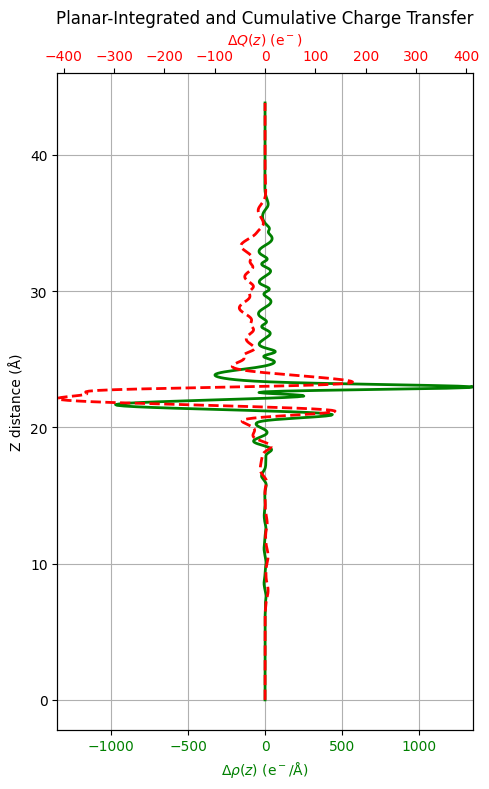

In [14]:
from pymatgen.io.vasp.outputs import Chgcar
import numpy as np
import matplotlib.pyplot as plt

# Load CHGDIFF = ρ_interface - ρ_SiC - ρ_Ga2O3
chg_diff = Chgcar.from_file("CHGDIFF.vasp")

# Planar average (e⁻/Å³)
z_avg = chg_diff.get_average_along_axis(2)

# Geometry
lattice = chg_diff.structure.lattice
area = np.linalg.norm(np.cross(lattice.matrix[0], lattice.matrix[1]))  # Å²
c_length = lattice.c
z = np.linspace(0, c_length, len(z_avg))
dz = c_length / len(z_avg)

# Convert to e⁻/Å and integrate to get e⁻
rho_ave = z_avg * area               # Δρ(z) in e⁻/Å
rho_integrated = np.cumsum(rho_ave) * dz  # ΔQ(z) in e⁻

# Plotting: taller figure and aligned x-axes
fig, ax1 = plt.subplots(figsize=(5, 8))  # Taller figure (height=8)

# Δρ(z) plot on bottom x-axis
color1 = 'green'
ax1.plot(rho_ave, z, color=color1, linewidth=2, label=r'$\Delta\rho(z)$')
ax1.set_xlabel(r'$\Delta\rho(z)$ (e$^-$/Å)', color=color1)
ax1.set_ylabel('Z distance (Å)')
ax1.tick_params(axis='x', labelcolor=color1)
ax1.grid(True)

# ΔQ(z) plot on top x-axis
ax2 = ax1.twiny()
color2 = 'red'
ax2.plot(rho_integrated, z, color=color2, linestyle='--', linewidth=2, label=r'$\Delta Q(z)$')
ax2.set_xlabel(r'$\Delta Q(z)$ (e$^-)$', color=color2)
ax2.tick_params(axis='x', labelcolor=color2)

# Align both axes to the same zero position
# Set symmetric x-limits based on max absolute value
x1_lim = max(abs(rho_ave.min()), abs(rho_ave.max()))
x2_lim = max(abs(rho_integrated.min()), abs(rho_integrated.max()))
ax1.set_xlim(-x1_lim, x1_lim)
ax2.set_xlim(-x2_lim, x2_lim)

plt.title("Planar-Integrated and Cumulative Charge Transfer")
plt.tight_layout()
plt.savefig("dual_charge_profile_aligned.png", dpi=300, bbox_inches='tight')
plt.show()


In [19]:
rho_ave = z_avg  # Already in e⁻/Å
rho_integrated = np.cumsum(rho_ave) * dz  # Now in e⁻

print("In-plane area (Å²):", area)
rho_ave_norm = rho_ave / area   # now in e⁻/Å² (optional normalization)
rho_integrated_norm = rho_integrated / area  # e⁻/Å

print(f"Total ΔQ (min, max): {rho_integrated.min():.4f} e⁻ → {rho_integrated.max():.4f} e⁻")
print(lattice)

In-plane area (Å²): 24.534487824
Total ΔQ (min, max): -16.8116 e⁻ → 7.0818 e⁻
3.073000 0.000000 0.000000
1.536500 7.983888 0.000000
0.000000 0.000000 43.800568


In [45]:
from pymatgen.io.vasp.outputs import Chgcar
import numpy as np
import matplotlib.pyplot as plt

chg = Chgcar.from_file("./inter_dipole/CHGCAR")   # valence-only CHGCAR !
# print(chg.shape)
print(chg.structure)                 # Full atomic structure from POSCAR
print(chg.structure.composition)     # Chemical formula / atom counts
print(chg.structure.lattice)         # Lattice parameters (a, b, c)

Full Formula (Ga12 Si18 H3 C18 O18)
Reduced Formula: Ga4Si6H(CO)6
abc   :   3.073000   8.130394  43.800568
angles:  90.000000  90.000000  79.106605
pbc   :       True       True       True
Sites (69)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ga    0.198816  0.597797  0.603419
  1  Ga    0.511695  0.971931  0.60366
  2  Ga    0.852557  0.289964  0.562767
  3  Ga    0.088768  0.822104  0.538741
  4  Ga    0.974983  0.046928  0.707601
  5  Ga    0.293759  0.409206  0.708462
  6  Ga    0.630884  0.735544  0.669183
  7  Ga    0.859327  0.277272  0.642023
  8  Ga    0.74888   0.499633  0.808459
  9  Ga    0.072722  0.852229  0.81799
 10  Ga    0.416199  0.166167  0.774947
 11  Ga    0.636259  0.724424  0.745784
 12  O     0.534017  0.931739  0.521668
 13  O     0.411488  0.172393  0.576078
 14  O     0.863592  0.274733  0.521941
 15  O     0.076477  0.84314   0.58042
 16  O     0.191889  0.617455  0.521261
 17  O     0.743725  0.507839  0.580807
 18

In [ ]:
from pymatgen.io.vasp.outputs import Chgcar
import numpy as np

chg = Chgcar.from_file("./SiCH_dipole/CHGCAR")
grid = chg.data["total"]              # raw grid: unitless electrons per point



nx, ny, nz = grid.shape
latt = chg.structure.lattice
dz = latt.c / nz                      # Å
area = np.linalg.norm(np.cross(latt.matrix[0], latt.matrix[1]))  # Å²
voxel_volume = latt.volume / (nx * ny * nz)  # Å³

# Convert grid to charge density (e⁻/Å³)
grid_density = grid / voxel_volume   # now has correct physical units

# Sum over x, y to get planar average in z (e⁻/Å³ × area = e⁻/Å)
rho_ave = grid_density.sum(axis=(0, 1)) * voxel_volume  # e⁻/Å

# Total charge from planar average (sanity check)
total_electrons = np.sum(rho_ave) * dz  # e⁻
print(f"Total valence electrons from CHGCAR: {total_electrons:.4f} e⁻")

# Stats
print(f"ρ_ave max: {np.max(rho_ave):.4e} e⁻/Å")
print(f"ρ_ave min: {np.min(rho_ave):.4e} e⁻/Å")
print(f"ρ_ave mean: {np.mean(rho_ave):.4e} e⁻/Å")


Total valence electrons from CHGCAR: 57690604.1399 e⁻
ρ_ave max: 6.2183e+06 e⁻/Å
ρ_ave min: -1.7807e+00 e⁻/Å
ρ_ave mean: 1.3171e+06 e⁻/Å


In [54]:



# ----- basic information -------------------------------------------------
grid = chg.data["total"]           # (nx, ny, nz) array
nx, ny, nz = grid.shape
latt = chg.structure.lattice
dz    = latt.c / nz                # Å
area  = np.linalg.norm(            # in-plane area Å²
          np.cross(latt.matrix[0], latt.matrix[1]))
print(latt)
print(dz, area)  # print grid spacing and in-plane area
print(f"Grid shape: {grid.shape}  (nx, ny, nz) = ({nx}, {ny}, {nz})")
print(grid[0, 0, 0])  # print first voxel value (should be ~0.0)
# # ----- total valence electrons (sanity check) ----------------------------
# valence_e = grid.sum()             # direct sum of all voxels
# print(f"Total valence e⁻ from CHGCAR   : {valence_e:.2f}")
# should match POTCAR: 18 Si ×4 + 18 C ×4 + 3 H ×1  = 147 e⁻

# # ----- electrons in every z-slice ---------------------------------------
e_slice = grid.sum(axis=(0, 1))    # shape (nz,),   electrons in each slice
voxel_volume = latt.volume / (nx * ny * nz)
grid_electron = grid * voxel_volume  # now in e⁻ per voxel
e_slice = grid_electron.sum(axis=(0, 1))  # proper electrons per z-slice
print(max(e_slice), min(e_slice), np.mean(e_slice))  # sanity check
import numpy as np

# Let's assume e_slice is your array of electrons per z-slice
# And dz is the spacing between z points
z = np.linspace(0, dz * len(e_slice), len(e_slice), endpoint=False)

# Stack z and e_slice into two columns
data = np.column_stack((z, e_slice))  # shape: (nz, 2)

# Save to text file with header
np.savetxt("e_slice.txt", data, fmt="%.6f", header="z (Å)    electrons per slice", comments='')


print("=== Sanity Check: EDD Profile ===")
print(f"Lattice c (z-length): {latt.c:.4f} Å")
print(f"Grid shape: (nx, ny, nz) = ({nx}, {ny}, {nz})")
print(f"Grid spacing dz = {dz:.6f} Å")
print(f"In-plane area = {area:.4f} Å²")
print(f"Voxel volume = {voxel_volume:.6e} Å³")

# Total valence electrons (for CHGCAR, not CHGCAR_diff)
print(f"Total valence electrons (grid sum): {grid.sum():.4f} e⁻")
print(f"Total electrons from e_slice: {e_slice.sum():.4f} e⁻")

# Planar-averaged charge density
rho_ave = e_slice / dz
print(f"ρ_ave(z) units: e⁻/Å")  # Planar-averaged along z
print(f"ρ_ave max: {np.max(rho_ave):.4f} e⁻/Å")
print(f"ρ_ave min: {np.min(rho_ave):.4f} e⁻/Å")
print(f"ρ_ave mean: {np.mean(rho_ave):.4e} e⁻/Å")

# Cumulative charge
delta_Q = np.cumsum(rho_ave) * dz
print(f"ΔQ(z) (cumulative charge):")
print(f"ΔQ range: {delta_Q.min():.4f} e⁻ → {delta_Q.max():.4f} e⁻")

# rho_ave = e_slice / dz             # Eq.(3)   e Å⁻¹
# delta_Q = np.cumsum(e_slice)       # Eq.(4)   cumulative e

# # ----- quick plots -------------------------------------------------------
# z = np.linspace(0, latt.c, nz)

# fig, ax1 = plt.subplots(figsize=(4, 7))
# ax1.plot(rho_ave, z, 'g', label=r'$\Delta\rho_{\rm ave}(z)$')
# ax1.set_xlabel(r'$\Delta\rho_{\rm ave}(z)$  (e Å$^{-1}$)', color='g')
# ax1.set_ylabel('z (Å)')
# ax1.tick_params(axis='x', colors='g')

# ax2 = ax1.twiny()
# ax2.plot(delta_Q, z, 'r--', label=r'$\Delta Q(z)$')
# ax2.set_xlabel(r'$\Delta Q(z)$  (e)', color='r')
# ax2.tick_params(axis='x', colors='r')

# plt.title('Planar-integrated charge and cumulative transfer')
# plt.tight_layout()
# plt.savefig('charge_profile.png', dpi=300)
# plt.show()


3.073000 0.000000 0.000000
1.536500 7.983888 0.000000
0.000000 0.000000 43.800568
0.05214353333333333 24.534487824
Grid shape: (56, 160, 840)  (nx, ny, nz) = (56, 160, 840)
0.0001458857131
887.8589038516285 -0.00025425077923147327 188.05928795034635
=== Sanity Check: EDD Profile ===
Lattice c (z-length): 43.8006 Å
Grid shape: (nx, ny, nz) = (56, 160, 840)
Grid spacing dz = 0.052144 Å
In-plane area = 24.5345 Å²
Voxel volume = 1.427807e-04 Å³
Total valence electrons (grid sum): 1106380800.3018 e⁻
Total electrons from e_slice: 157969.8019 e⁻
ρ_ave(z) units: e⁻/Å
ρ_ave max: 17027.2102 e⁻/Å
ρ_ave min: -0.0049 e⁻/Å
ρ_ave mean: 3.6066e+03 e⁻/Å
ΔQ(z) (cumulative charge):
ΔQ range: 0.0002 e⁻ → 157969.8031 e⁻


In [4]:
from pymatgen.io.vasp.outputs import Chgcar
import numpy as np

# Load CHGCAR (valence-only or full depending on what you have)
chg = Chgcar.from_file("./GaO_dipole/CHGCAR")

# Get charge density grid (unit: e⁻/Å³ at each grid point)
grid = chg.data["total"]
nx, ny, nz = grid.shape

# Get voxel volume (in Å³)
voxel_volume = chg.structure.lattice.volume / (nx * ny * nz)

# Multiply by voxel volume to get e⁻ per voxel
grid_electrons = grid * voxel_volume

# Total valence electrons from CHGCAR
total_electrons = grid_electrons.sum()

print(f"Total electrons from CHGCAR: {total_electrons:.4f} e⁻")


Total electrons from CHGCAR: 283700.8706 e⁻


In [3]:
from pymatgen.io.vasp.inputs import Potcar
from pymatgen.core import Structure
import os

# Load structure to get atom counts
structure = Structure.from_file("./GaO_dipole/POSCAR")

# Load POTCAR (concatenated for all elements)
potcar = Potcar.from_file("./GaO_dipole/POTCAR")

# Extract ZVAL from each potential
valence_dict = {}
for pot in potcar:
    element = pot.symbol.split("_")[0]
    zval = float(pot.keywords["ZVAL"])  # ✅ Access ZVAL correctly
    valence_dict[element] = zval

# Compute total valence electrons
total_valence = 0
print("Element-wise valence electron count:")
for el in structure.composition:
    count = structure.composition[el]
    zval = valence_dict[el.symbol]
    total = zval * count
    total_valence += total
    print(f"  {el.symbol:>2} × {int(count):>3} × {zval:>4} e⁻ = {total:>7.2f} e⁻")

print(f"\n🔢 Total valence electrons in structure: {total_valence:.2f} e⁻")

Element-wise valence electron count:
  Ga ×  12 × 13.0 e⁻ =  156.00 e⁻
   O ×  18 ×  6.0 e⁻ =  108.00 e⁻

🔢 Total valence electrons in structure: 264.00 e⁻


Planar Average Potential

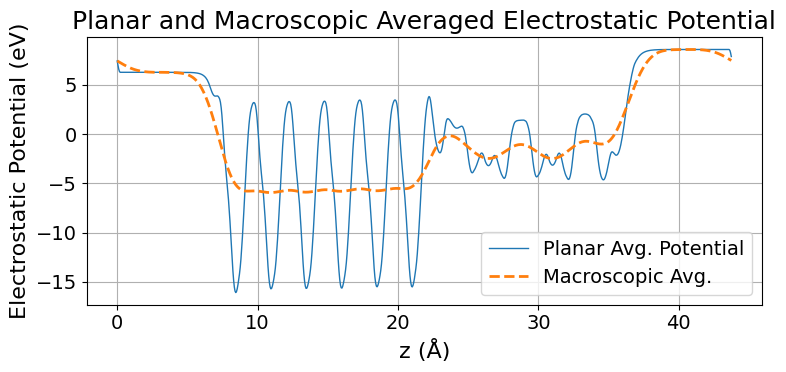

Vacuum left:  6.488 eV
Vacuum right: 8.366 eV
Vacuum level: 8.366 eV
Potential step ΔV: -1.878 eV
Interface dipole moment: -0.10 Debye


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Load MACROSCOPIC_AVERAGE.dat: columns = z, macroscopic_avg, planar_avg
data = np.loadtxt("./inter_dipole/MACROSCOPIC_AVERAGE.dat", comments="#")
z = data[:, 0]
macro_avg = data[:, 1]
planar_avg = data[:, 2]

# Basic spacing and plotting setup
dz = z[1] - z[0]  # spacing in Å

# ---- Plotting ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

plt.figure(figsize=(8, 4))
plt.plot(z, planar_avg, label="Planar Avg. Potential", lw=1)
plt.plot(z, macro_avg, label="Macroscopic Avg.", lw=2, linestyle='--')

plt.xlabel("z (Å)")
plt.ylabel("Electrostatic Potential (eV)")
plt.title("Planar and Macroscopic Averaged Electrostatic Potential")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("electrostatic_potential_from_macroscopic_avg.png", dpi=300)
plt.show()

# ---- Analyze Vacuum Level and ΔV ----
n = len(z)
vacuum_left = np.mean(macro_avg[:int(0.1 * n)])
vacuum_right = np.mean(macro_avg[-int(0.1 * n):])
vacuum_level = max(vacuum_left, vacuum_right)
delta_V = vacuum_left - vacuum_right

print(f"Vacuum left:  {vacuum_left:.3f} eV")
print(f"Vacuum right: {vacuum_right:.3f} eV")
print(f"Vacuum level: {vacuum_level:.3f} eV")
print(f"Potential step ΔV: {delta_V:.3f} eV")

# ---- Calculate Dipole Moment (Debye) ----
epsilon_0 = 8.854187817e-12  # F/m
A_ang2 = 25  # In-plane area in Å² (replace with actual value!)
A_m2 = A_ang2 * 1e-20
mu_Cm = delta_V * epsilon_0 * A_m2 / (4 * np.pi)  # in C·m
mu_Debye = mu_Cm / (3.33564e-30)  # in Debye

print(f"Interface dipole moment: {mu_Debye:.2f} Debye")


PDOS plot

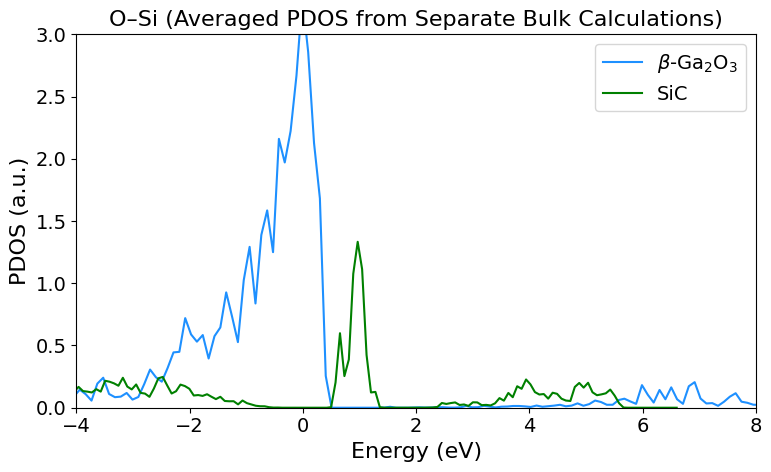

In [23]:
from pymatgen.io.vasp.outputs import Vasprun
import matplotlib.pyplot as plt
import numpy as np

# === Load vasprun.xml from both systems ===
vasprun_o = Vasprun("./GaO_dipole/vasprun.xml")
vasprun_si = Vasprun("./SiCH_dipole/vasprun.xml")

complete_dos_o = vasprun_o.complete_dos
complete_dos_si = vasprun_si.complete_dos



efermi_o = vasprun_o.efermi
efermi_si = vasprun_si.efermi

# === Extract energies shifted by respective Fermi levels ===
energies_o = complete_dos_o.energies - efermi_o
energies_si = complete_dos_si.energies - efermi_si

# for i, site in enumerate(complete_dos_si.structure):
#     print(f"{i}: {site.species_string}, coords: {site.frac_coords}")
# === Atom indices (from each structure separately) ===
o_indices = [12, 14, 16]
si_indices = [9, 10, 11]

# === Initialize PDOS arrays ===
pdos_o_total = np.zeros_like(energies_o)
pdos_si_total = np.zeros_like(energies_si)

# === Sum PDOS for O atoms (Ga2O3) ===
for idx in o_indices:
    site = complete_dos_o.structure[idx]
    site_dos = complete_dos_o.get_site_dos(site)
    pdos_sum = sum(site_dos.densities[orb] for orb in site_dos.densities)
    pdos_o_total += pdos_sum

# === Sum PDOS for Si atoms (SiC) ===
for idx in si_indices:
    site = complete_dos_si.structure[idx]
    site_dos = complete_dos_si.get_site_dos(site)
    pdos_sum = sum(site_dos.densities[orb] for orb in site_dos.densities)
    pdos_si_total += pdos_sum

# === Average (optional) ===
pdos_o_avg = pdos_o_total / len(o_indices)
pdos_si_avg = pdos_si_total / len(si_indices)

# === Optional manual alignment (e.g., VBM offset 0.92 eV) ===
# You can shift one side if needed for interface alignment
vbo = 0.92  # valence band offset between Ga2O3 and SiC
energies_si_shifted = energies_si + vbo

# === Plot ===
plt.figure(figsize=(8, 5))
plt.plot(energies_o, pdos_o_avg, label=r'$\beta$-Ga$_2$O$_3$', color='dodgerblue')
plt.plot(energies_si_shifted, pdos_si_avg, label='SiC', color='green')

# ---- Plotting ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
# Optional band offset annotation
# plt.axvline(x=-2.00, color='k', linestyle='--')
# plt.axvline(x=-2.92, color='k', linestyle='--')
# plt.annotate("0.92 eV", xy=(-2.5, 1), xytext=(-3.5, 3),
#              arrowprops=dict(arrowstyle='<->'), fontsize=12)

plt.xlabel('Energy (eV)')
plt.ylabel('PDOS (a.u.)')
plt.xlim(-4, 8)
plt.ylim(0, 3)
plt.title("O–Si (Averaged PDOS from Separate Bulk Calculations)")
plt.legend()
plt.tight_layout()
plt.show()


Calculate Band Gap

Fermi level: 3.792 eV
Ga₂O₃ atoms selected: 30
SiC atoms selected: 18
Saved PDOS files for both sides.
Ga₂O₃ VBM: -0.027 eV, CBM: 0.047 eV, Gap: 0.074 eV
SiC    VBM: -1.185 eV, CBM: 1.131 eV, Gap: 2.317 eV


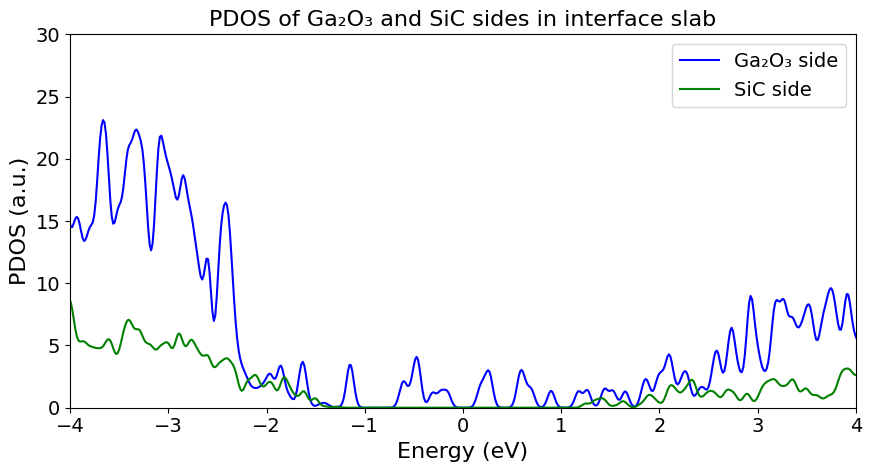

In [38]:
from pymatgen.io.vasp.outputs import Vasprun
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# === Load vasprun.xml from interface calculation ===
vasprun = Vasprun("./inter_dipole/vasprun.xml")
complete_dos = vasprun.complete_dos
structure = complete_dos.structure
efermi = vasprun.efermi
print(f"Fermi level: {efermi:.3f} eV")

energies = complete_dos.energies - efermi  # Align to Fermi level

# === Define Z-cutoff to separate Ga2O3 and SiC sides ===
z_cut = 15.0  # adjust based on your slab geometry

# === Select Ga2O3 atoms (Ga, O) above z_cut ===
ga2o3_indices = [i for i, site in enumerate(structure)
                 if site.species_string in ['Ga', 'O'] and site.coords[2] > z_cut]

# === Select SiC atoms (Si, C) below z_cut ===
sic_indices = [i for i, site in enumerate(structure)
               if site.species_string in ['Si', 'C'] and site.coords[2] < z_cut]

print(f"Ga₂O₃ atoms selected: {len(ga2o3_indices)}")
print(f"SiC atoms selected: {len(sic_indices)}")

# === Get total PDOS for Ga2O3 side ===
pdos_ga2o3 = np.zeros_like(energies)
for idx in ga2o3_indices:
    site_dos = complete_dos.get_site_dos(structure[idx])
    total = sum(site_dos.densities[orb] for orb in site_dos.densities)
    pdos_ga2o3 += total

# === Get total PDOS for SiC side ===
pdos_sic = np.zeros_like(energies)
for idx in sic_indices:
    site_dos = complete_dos.get_site_dos(structure[idx])
    total = sum(site_dos.densities[orb] for orb in site_dos.densities)
    pdos_sic += total

# === Smooth both with Gaussian filter ===
sigma = 1.0
# pdos_ga2o3_smoothed = gaussian_filter1d(pdos_ga2o3, sigma=sigma)
# pdos_sic_smoothed = gaussian_filter1d(pdos_sic, sigma=sigma)

pdos_ga2o3_smoothed = pdos_ga2o3
pdos_sic_smoothed = pdos_sic

# === Save both to file ===
np.savetxt("PDOS_Ga2O3_smoothed.txt", np.column_stack((energies, pdos_ga2o3_smoothed)),
           header="Energy (eV)    Ga2O3 Smoothed PDOS", fmt="%.6f")
np.savetxt("PDOS_SiC_smoothed.txt", np.column_stack((energies, pdos_sic_smoothed)),
           header="Energy (eV)    SiC Smoothed PDOS", fmt="%.6f")
print("Saved PDOS files for both sides.")

# === Find VBM and CBM for each side ===
def get_vbm_cbm(energies, pdos, threshold=1e-3):
    vbm = max(e for e, d in zip(energies, pdos) if e < 0 and d > threshold)
    cbm = min(e for e, d in zip(energies, pdos) if e > 0 and d > threshold)
    return vbm, cbm, cbm - vbm

vbm_g, cbm_g, gap_g = get_vbm_cbm(energies, pdos_ga2o3_smoothed)
vbm_s, cbm_s, gap_s = get_vbm_cbm(energies, pdos_sic_smoothed)

print(f"Ga₂O₃ VBM: {vbm_g:.3f} eV, CBM: {cbm_g:.3f} eV, Gap: {gap_g:.3f} eV")
print(f"SiC    VBM: {vbm_s:.3f} eV, CBM: {cbm_s:.3f} eV, Gap: {gap_s:.3f} eV")

# === Plot both on same figure ===
# ---- Plotting ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
plt.figure(figsize=(9, 5))
plt.plot(energies, pdos_ga2o3_smoothed, label="Ga₂O₃ side", color="blue")
plt.plot(energies, pdos_sic_smoothed, label="SiC side", color="green")

# Annotate band edges
# plt.axvline(vbm_g, color='blue', linestyle='--', label=f'Ga₂O₃ VBM = {vbm_g:.2f} eV')
# plt.axvline(cbm_g, color='blue', linestyle='-.', label=f'Ga₂O₃ CBM = {cbm_g:.2f} eV')
# plt.axvline(vbm_s, color='green', linestyle='--', label=f'SiC VBM = {vbm_s:.2f} eV')
# plt.axvline(cbm_s, color='green', linestyle='-.', label=f'SiC CBM = {cbm_s:.2f} eV')

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("PDOS (a.u.)")
plt.title("PDOS of Ga₂O₃ and SiC sides in interface slab")
plt.legend()
plt.xlim(-4, 4)
plt.ylim(0, 30)
plt.tight_layout()
plt.show()
